<a href="https://colab.research.google.com/github/2521812022/Parcial4_CorenaGomez_2521812022/blob/main/Notebooks/Asociaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Ejercicio 1: Análisis de Asociación (Reglas de Asociación)

In [30]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

# Cargar el archivo CSV normal (separado por comas por defecto)
url_asociacion = "https://raw.githubusercontent.com/2521812022/Parcial4_CorenaGomez_2521812022/refs/heads/main/clave_C_asociacion.csv"
df_aso = pd.read_csv(url_asociacion)

# Mostrar las primeras filas del dataset
print(df_aso.head())

  transaccion_id cliente_id       fecha   categoria           item  cantidad  \
0        C-T0001    C-C0094  2026-01-01       Redes         Router         1   
1        C-T0002    C-C0001  2026-01-15     Computo         Laptop         2   
2        C-T0002    C-C0001  2026-01-15     Computo          Mouse         1   
3        C-T0003    C-C0067  2026-03-15       Redes      Adaptador         1   
4        C-T0003    C-C0067  2026-03-15  Accesorios  Disco_externo         2   

    canal  
0     Web  
1  Tienda  
2  Tienda  
3     Web  
4     Web  


**Explicación de la estructura:**
El dataset original es de tipo transaccional (formato largo). Cada fila representa un artículo individual comprado dentro de una transacción.
* `transaccion_id`: Identificador único de la compra (canasta).
* `cliente_id`: Identificador del cliente.
* `fecha`: Fecha de la transacción.
* `categoria` e `item`: Clasificación y nombre del producto comprado.
* `cantidad`: Unidades compradas de ese ítem.
* `canal`: Por dónde se hizo la compra (Ej. Web o Tienda).

## 2. Verificar valores nulos, duplicados y tipos de datos
Antes de aplicar el modelo, debemos asegurar la calidad de los datos.

In [31]:
print("--- Tipos de Datos y Valores Nulos ---")
df_aso.info()

print("\n--- Conteo de Valores Nulos ---")
print(df_aso.isnull().sum())

print("\n--- Registros Duplicados ---")
print("Cantidad de duplicados exactos:", df_aso.duplicated().sum())

'--- Tipos de Datos y Valores Nulos ---'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 601 entries, 0 to 600
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   transaccion_id  601 non-null    object
 1   cliente_id      601 non-null    object
 2   fecha           601 non-null    object
 3   categoria       601 non-null    object
 4   item            601 non-null    object
 5   cantidad        601 non-null    int64 
 6   canal           600 non-null    object
dtypes: int64(1), object(6)
memory usage: 33.0+ KB

--- Conteo de Valores Nulos ---
transaccion_id    0
cliente_id        0
fecha             0
categoria         0
item              0
cantidad          0
canal             1
dtype: int64

--- Registros Duplicados ---
Cantidad de duplicados exactos: 1


## 3. Preparación de los datos
Para utilizar el algoritmo Apriori, necesitamos transformar este formato transaccional a una matriz booleana (formato ancho). Cada fila será un único `transaccion_id` y cada columna será un `item`. Las celdas indicarán con `True` o `False` si el producto está presente en esa transacción.

In [32]:
# Crear la matriz de canasta de compra (basket) sumando cantidades por transacción
basket = (df_aso.groupby(['transaccion_id', 'item'])['cantidad']
          .sum().unstack().reset_index().fillna(0)
          .set_index('transaccion_id'))

# Función para codificar en variables booleanas (True/False)
def encode_units(x):
    if x <= 0:
        return False
    if x >= 1:
        return True

# Aplicamos la función a la matriz usando .map()
basket_sets = basket.map(encode_units)

# Mostrar la matriz preparada
print(basket_sets.head())

item            Adaptador  Antivirus  Audifonos  Backup  Cable_red  Cargador  \
transaccion_id                                                                 
C-T0001             False      False      False   False      False     False   
C-T0002             False      False      False   False      False     False   
C-T0003              True      False      False   False      False     False   
C-T0004             False      False      False   False      False     False   
C-T0005             False      False      False   False      False     False   

item            Celular  Disco_externo    Hub  Laptop  Licencia_cloud  \
transaccion_id                                                          
C-T0001           False          False  False   False           False   
C-T0002           False          False  False    True           False   
C-T0003           False           True  False    True           False   
C-T0004           False          False  False   False            True   
C

## 4. Aplicar el algoritmo Apriori y Generar Reglas
Generamos los itemsets frecuentes usando un **soporte mínimo del 5%** y extraemos las reglas calculando **confianza** y **lift**.

In [ ]:
# 1. Aplicar Apriori para encontrar combinaciones frecuentes
frequent_itemsets = apriori(basket_sets, min_support=0.05, use_colnames=True)

# 2. Generar reglas de asociación
reglas = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

# Filtrar por confianza mínima y ordenar para mostrar las más relevantes
reglas = reglas.sort_values(['confidence', 'lift'], ascending=[False, False])

## 5. Mostrar las 10 reglas más relevantes
A continuación se muestran las combinaciones más fuertes ordenadas por confianza y lift.

In [33]:
# Seleccionar columnas clave para la lectura del negocio
top_10_reglas = reglas[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)
print(top_10_reglas)

              antecedents  consequents   support  confidence      lift
34        (Mouse, Laptop)    (Mochila)  0.114286    0.909091  3.384913
32       (Mochila, Mouse)     (Laptop)  0.114286    0.909091  3.314394
27   (Protector, Celular)   (Cargador)  0.091429    0.888889  3.888889
28    (Cargador, Celular)  (Protector)  0.091429    0.842105  4.912281
26  (Protector, Cargador)    (Celular)  0.091429    0.800000  3.888889
33      (Mochila, Laptop)      (Mouse)  0.114286    0.800000  3.783784
14            (Protector)   (Cargador)  0.114286    0.666667  2.916667
18            (Protector)    (Celular)  0.102857    0.600000  2.916667
25                (Mouse)    (Mochila)  0.125714    0.594595  2.213916
22                (Mouse)     (Laptop)  0.125714    0.594595  2.167793


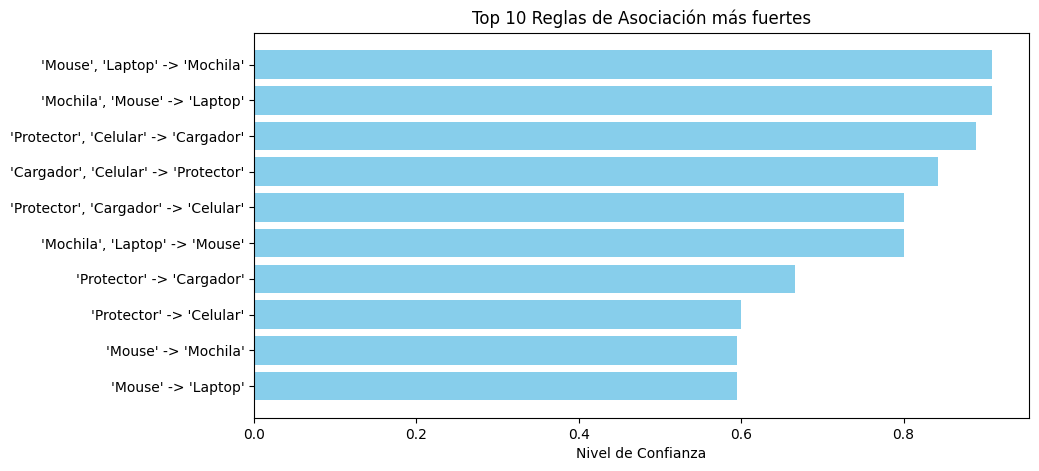

In [ ]:
import matplotlib.pyplot as plt

# Crear un texto combinando antecedente y consecuente para las etiquetas
etiquetas = top_10_reglas['antecedents'].astype(str) + " -> " + top_10_reglas['consequents'].astype(str)
etiquetas = etiquetas.str.replace("frozenset", "").str.replace("({", "").str.replace("})", "")

# Generar el gráfico de barras horizontales
plt.figure(figsize=(10, 5))
plt.barh(etiquetas, top_10_reglas['confidence'], color='skyblue')
plt.xlabel('Nivel de Confianza')
plt.title('Top 10 Reglas de Asociación más fuertes')
plt.gca().invert_yaxis() # La mejor regla arriba
plt.show()

## 6. Interpretación de 5 Reglas (Lenguaje de Negocio)

1. **Protector -> Cargador:** El 66.6% de los clientes que compran un protector también compran un cargador. Su compra conjunta ocurre casi 3 veces más de lo que se esperaría por azar (Lift = 2.91), indicando un comportamiento fuerte de "kit de protección y carga" para dispositivos móviles.
2. **Protector -> Celular:** El 60.0% de quienes compran un protector, de hecho llevan también el celular en la misma transacción (Lift = 2.91). Esto confirma que el protector es una compra complementaria casi obligatoria y de impulso al comprar un dispositivo nuevo.
3. **Mouse -> Mochila:** Existe una confianza del 59.4% de que alguien que adquiere un mouse se lleve una mochila. Esto refleja a un segmento de clientes (probablemente estudiantes o profesionales) renovando sus accesorios de transporte junto con sus periféricos.
4. **Mouse -> Laptop:** De manera similar, el 59.4% de los clientes que compran un mouse llevan una Laptop (Lift = 2.16). Es completamente natural que quien adquiere equipo de cómputo, adquiera de inmediato un periférico de control.
5. **Cable de Red -> Router:** El 53.1% de los que compran un Cable de red se llevan un Router. Un Lift de 2.65 demuestra que esta asociación es estratégica; el cliente está adquiriendo lo necesario para montar o mejorar su infraestructura de conexión.

---

## 7. Recomendaciones Comerciales y Conclusiones

1. **Estrategia "Bundle" o Combos (Cómputo):** Crear un combo promocional "Regreso a clases/Oficina" que incluya `Laptop + Mouse + Mochila` con un ligero descuento. Al ver la alta asociación cruzada, empaquetarlos simplificará la decisión del cliente y aumentará el valor promedio de la compra (ticket promedio).
2. **Venta Cruzada Inteligente (Mobile):** Configurar el sistema de la tienda web para que, al agregar un `Celular` o un `Protector` al carrito de compras, se despliegue inmediatamente un `Cargador` como sugerencia de "Productos complementarios recomendados".
3. **Optimización de Exhibición (Redes):** En tienda física, colocar el exhibidor de `Cables de red` contiguo a la sección de `Routers`. En el canal digital, mostrar recordatorios en el checkout de la página web para asegurar que el cliente no olvide comprar los accesorios de instalación de sus redes.